In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier, IsolationForest, VotingClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC, OneClassSVM
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import StratifiedKFold


# Load your data
# data = pd.read_csv('your_email_data.csv')  # Replace with your actual CSV file path
# For example purposes, assume 'text' and 'label' columns are present in the dataset
# data = pd.DataFrame({'text': ['email1', 'email2', 'email3'], 'label': ['Phishing', 'Legitimate', 'Phishing']})
#data = pd.read_csv("C:\\Users\\sobha\\Downloads\\Phishing_Email.csv\\Phishing_Email.csv")
data = pd.read_csv("C:\\Users\\sobha\\Downloads\\enron_spam_data\\enron_spam_data.csv")
data.dropna(inplace=True)

# Encode the labels (assuming 'Phishing' = 1, 'Legitimate' = 0)
label_encoder = LabelEncoder()
#data['Email Type'] = label_encoder.fit_transform(data['Email Type'])
data['Email Type'] = ['Phishing Email' if 'spam' in email else 'Safe Email' for email in data['Email Type']]
data['Email Type'] = label_encoder.fit_transform(data['Email Type'])
#data['Email Type'] = [1 if 'spam' in email else 0 for email in data['Email Type']]


# Split the data
X_train, X_test, y_train, y_test = train_test_split(data['Email Text'], data['Email Type'], test_size=0.2, random_state=42,  stratify=data['Email Type'])

# Define individual models for voting ensemble and separate evaluation
base_models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'AdaBoost': AdaBoostClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'Multinomial NB': MultinomialNB(),
    'SVM': SVC(kernel='linear', random_state=42),
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42),
    'LightGBM': LGBMClassifier(random_state=42),
    'Neural Network': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42),
    'One-Class SVM': OneClassSVM(kernel='rbf', gamma=0.01, nu=0.1),
    #'Isolation Forest': IsolationForest(n_estimators=100, random_state=42)
}

# Ensemble model with VotingClassifier (using majority voting for classifiers)
voting_model = VotingClassifier(
    estimators=[(name, model) for name, model in base_models.items() if name not in ['One-Class SVM', 'Isolation Forest']],
    voting='hard'
)

# Pipeline for processing and training each model
model_scores = {'Model': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': []}
print("Class distribution in y_train:", np.unique(y_train, return_counts=True))
skf = StratifiedKFold(n_splits=5)


C:\Users\sobha\AppData\Local\Temp\ipykernel_9296\671808407.py:24: DtypeWarning: Columns (0,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,2

Class distribution in y_train: (array([0]), array([2], dtype=int64))


Initiated:  Random Forest


c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 due to no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

Finished:  Random Forest
Initiated:  AdaBoost


c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sobha\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\sobha\AppData\Local\Programs\Python\Py

Finished:  AdaBoost
Initiated:  Gradient Boosting


ValueError: y contains 1 class after sample_weight trimmed classes with zero weights, while a minimum of 2 classes are required.

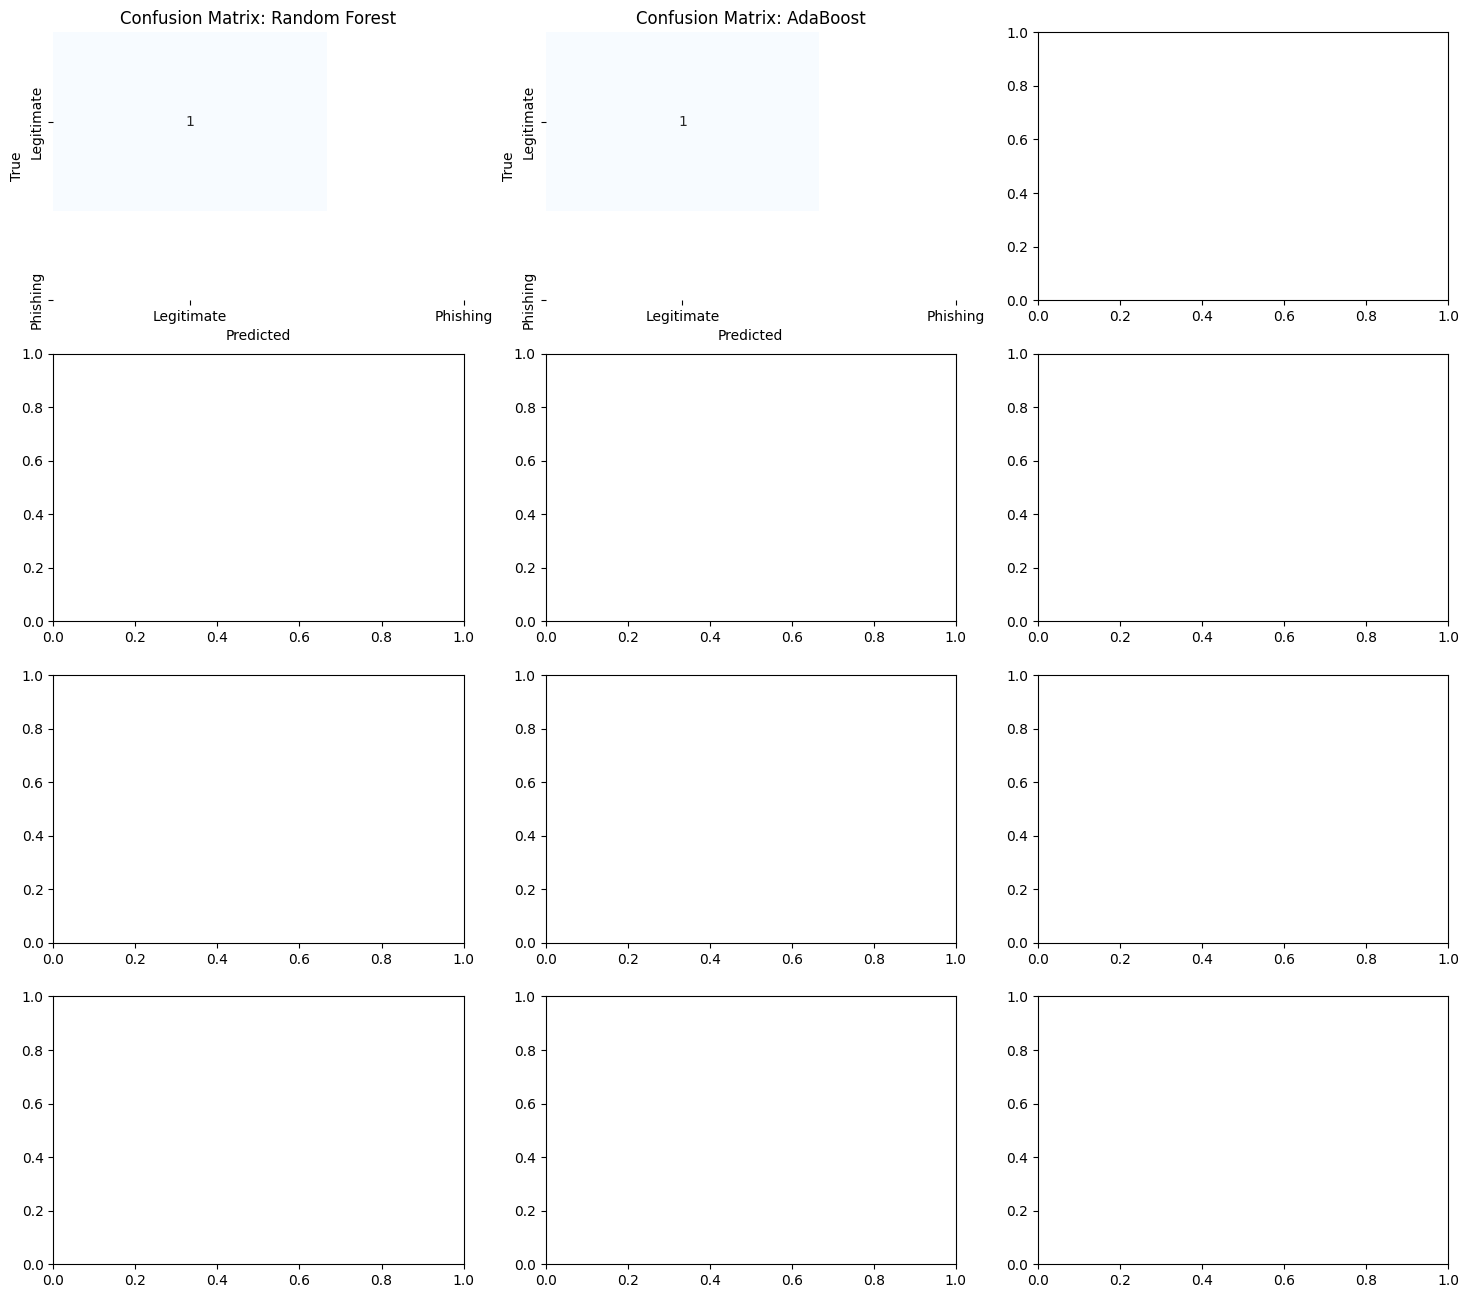

In [16]:
# Calculate grid size for confusion matrix subplots
num_models = len(base_models) + 1  # +1 for Voting Ensemble
num_cols = 3  # Adjust number of columns if needed
num_rows = (num_models + num_cols - 1) // num_cols  # Calculate required rows based on models

fig, axes = plt.subplots(num_rows, num_cols, figsize=(18, num_rows * 4))
axes = axes.flatten()

# Evaluate each model
for idx, (model_name, model) in enumerate({**base_models, 'Voting Ensemble': voting_model}.items()):
    print("Initiated: ", model_name)
    # Set up pipeline with TF-IDF transformation and model training
    pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(stop_words='english', max_features=5000)),
        ('classifier', model)
    ])
    
    # Handle anomaly detection models separately
    if model_name in ['One-Class SVM', 'Isolation Forest']:
        pipeline.fit(X_train)
        y_pred = pipeline.predict(X_test)
        y_pred = np.where(y_pred == 1, 0, 1)  # Map predictions to binary labels (1 = phishing)
    else:
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

    # Calculate metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    # Store results
    model_scores['Model'].append(model_name)
    model_scores['Accuracy'].append(acc)
    model_scores['Precision'].append(prec)
    model_scores['Recall'].append(rec)
    model_scores['F1 Score'].append(f1)

    # Confusion matrix plot
    conf_matrix = confusion_matrix(y_test, y_pred)
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'],
                ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix: {model_name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')
    print("Finished: ", model_name)

# Adjust layout for confusion matrices
plt.tight_layout()

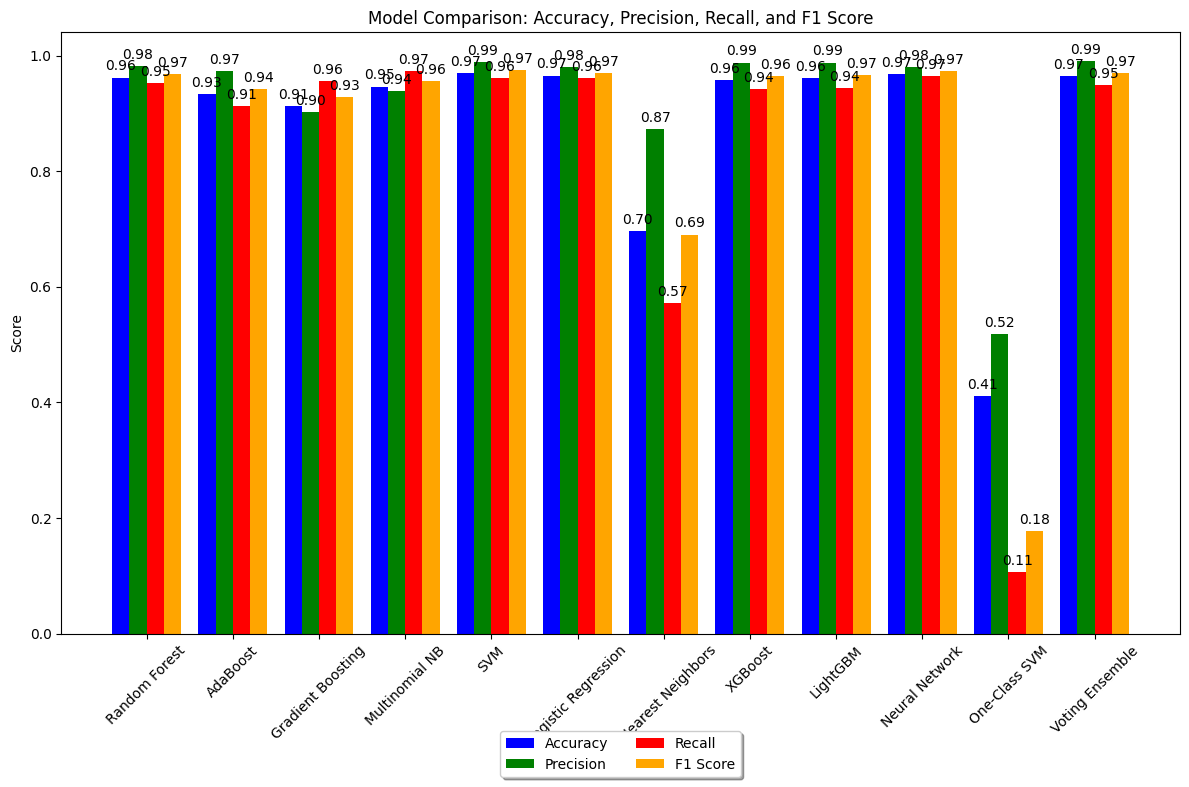

                  Model  Accuracy  Precision    Recall  F1 Score
0         Random Forest  0.962168   0.982276  0.953373  0.967609
1              AdaBoost  0.932922   0.972960  0.912177  0.941589
2     Gradient Boosting  0.913067   0.902950  0.956089  0.928760
3        Multinomial NB  0.946606   0.938099  0.974196  0.955807
4                   SVM  0.970754   0.989282  0.961068  0.974971
5   Logistic Regression  0.965656   0.980157  0.961521  0.970750
6   K-Nearest Neighbors  0.696539   0.872752  0.571299  0.690561
7               XGBoost  0.958680   0.988124  0.941603  0.964302
8              LightGBM  0.960558   0.988163  0.944771  0.965980
9        Neural Network  0.968071   0.980681  0.965143  0.972850
10        One-Class SVM  0.411859   0.518600  0.107288  0.177794
11      Voting Ensemble  0.965119   0.991025  0.949751  0.969949


In [ ]:
# Comparison plot for accuracy, precision, recall, and F1 score
fig2, ax2 = plt.subplots(figsize=(12, 8))
x = np.arange(len(model_scores['Model']))
width = 0.2  # Width of the bars

# Bar plot for accuracy, precision, recall, and F1 score
rects1 = ax2.bar(x - width*1.5, model_scores['Accuracy'], width, label='Accuracy', color='b')
rects2 = ax2.bar(x - width/2, model_scores['Precision'], width, label='Precision', color='g')
rects3 = ax2.bar(x + width/2, model_scores['Recall'], width, label='Recall', color='r')
rects4 = ax2.bar(x + width*1.5, model_scores['F1 Score'], width, label='F1 Score', color='orange')

# Annotate each bar with its value
def annotate_bars(rects):
    for rect in rects:
        height = rect.get_height()
        ax2.annotate(f'{height:.2f}',
                     xy=(rect.get_x() + rect.get_width() / 2, height),
                     xytext=(0, 3),  # Offset text above bars
                     textcoords="offset points",
                     ha='center', va='bottom')

annotate_bars(rects1)
annotate_bars(rects2)
annotate_bars(rects3)
annotate_bars(rects4)

# Labeling the plot
ax2.set_xlabel('Model')
ax2.set_ylabel('Score')
ax2.set_title('Model Comparison: Accuracy, Precision, Recall, and F1 Score')
ax2.set_xticks(x)
ax2.set_xticklabels(model_scores['Model'], rotation=45)
ax2.legend(loc='center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=True, ncol=2)

# Adjust layout for comparison plot
plt.tight_layout()
plt.show()

# Print model scores in the console
print(pd.DataFrame(model_scores))

In [ ]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)
#Cascading model 1
# Step 1: Initial Model - Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_tfidf, y_train)
rf_predictions_train = rf.predict(X_train_tfidf)
rf_predictions_test = rf.predict(X_test_tfidf)

# Step 2: Use Random Forest predictions as features for the next model
# Stack Random Forest predictions with the original TF-IDF features
X_train_stage2 = np.hstack((X_train_tfidf.toarray(), rf_predictions_train.reshape(-1, 1)))
X_test_stage2 = np.hstack((X_test_tfidf.toarray(), rf_predictions_test.reshape(-1, 1)))

# Step 3: Second Model - SVM, trained on the combined features
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_stage2, y_train)
svm_predictions_train = svm.predict(X_train_stage2)
svm_predictions_test = svm.predict(X_test_stage2)

# Step 4: Use SVM predictions as features for the final model
X_train_stage3 = np.hstack((X_train_stage2, svm_predictions_train.reshape(-1, 1)))
X_test_stage3 = np.hstack((X_test_stage2, svm_predictions_test.reshape(-1, 1)))

# Step 5: Final Model - Logistic Regression, trained on combined features
logistic = LogisticRegression(random_state=42)
logistic.fit(X_train_stage3, y_train)
final_predictions = logistic.predict(X_test_stage3)


Final Model Accuracy: 0.9622
Final Model Precision: 0.9823
Final Model Recall: 0.9534
Final Model F1 Score: 0.9676


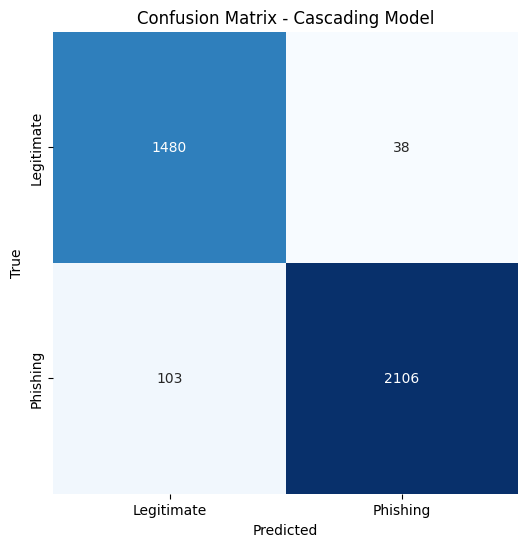

In [ ]:
# Calculate metrics for the final model
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions)
recall = recall_score(y_test, final_predictions)
f1 = f1_score(y_test, final_predictions)

# Display results
print(f"Final Model Accuracy: {accuracy:.4f}")
print(f"Final Model Precision: {precision:.4f}")
print(f"Final Model Recall: {recall:.4f}")
print(f"Final Model F1 Score: {f1:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix - Cascading Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
#cascading model 2

# Step 1: Initial Model - Gradient Boosting
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train_tfidf, y_train)
gb_predictions_train = gb.predict(X_train_tfidf)
gb_predictions_test = gb.predict(X_test_tfidf)

# Step 2: Use Gradient Boosting predictions as features for the next model
X_train_stage2 = np.hstack((X_train_tfidf.toarray(), gb_predictions_train.reshape(-1, 1)))
X_test_stage2 = np.hstack((X_test_tfidf.toarray(), gb_predictions_test.reshape(-1, 1)))

# Step 3: Second Model - SVM, trained on the combined features
svm = SVC(kernel='linear', random_state=42)
svm.fit(X_train_stage2, y_train)
svm_predictions_train = svm.predict(X_train_stage2)
svm_predictions_test = svm.predict(X_test_stage2)

# Step 4: Use SVM predictions as features for the final model
X_train_stage3 = np.hstack((X_train_stage2, svm_predictions_train.reshape(-1, 1)))
X_test_stage3 = np.hstack((X_test_stage2, svm_predictions_test.reshape(-1, 1)))

# Step 5: Final Model - Neural Network, trained on combined features
mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
mlp.fit(X_train_stage3, y_train)
final_predictions = mlp.predict(X_test_stage3)

Final Model Accuracy: 0.9683
Final Model Precision: 0.9852
Final Model Recall: 0.9611
Final Model F1 Score: 0.9730


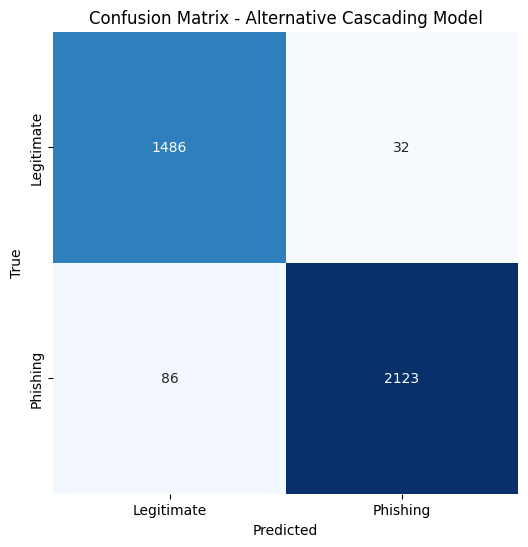

In [ ]:
# Calculate metrics for the final model
accuracy = accuracy_score(y_test, final_predictions)
precision = precision_score(y_test, final_predictions)
recall = recall_score(y_test, final_predictions)
f1 = f1_score(y_test, final_predictions)

# Display results
print(f"Final Model Accuracy: {accuracy:.4f}")
print(f"Final Model Precision: {precision:.4f}")
print(f"Final Model Recall: {recall:.4f}")
print(f"Final Model F1 Score: {f1:.4f}")

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, final_predictions)
plt.figure(figsize=(6, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Legitimate', 'Phishing'], yticklabels=['Legitimate', 'Phishing'])
plt.title('Confusion Matrix - Alternative Cascading Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()